# Beyond the Headlines: Rethinking Urban Heat Risk in Indian Cities

**Author:** Stuti Mishra  
**Date:** 2025–2026  
**Course:** Yale Environmental Data Science Certificate Program

## Research Questions

1. When measured against each city's own 30\-year historical baseline, rather than in absolute terms, which city is warming faster: Delhi or Bengaluru?
2. Do temperature anomaly trends suggest that Bengaluru's warming is being systematically underreported because headlines focus on absolute peak temperatures rather than relative change?

**GitHub Repository:** [urban-heat-india-capstone](https://github.com/stutimishra11/urban-heat-india-capstone)

---

## The Argument

Delhi regularly makes international headlines for record\-breaking heat. In recent years, temperatures in the Indian capital have approached and occasionally exceeded 50C, prompting emergency health advisories and widespread media coverage. Bengaluru, by contrast, is rarely discussed in the context of urban heat. Its temperatures are milder, its climate more moderate, and it has long been marketed as India's most liveable city.

But absolute temperature and *rate of warming* are two very different things.

A city that was already hot staying hot is not the same as a city that was mild becoming measurably warmer. Climate scientists measure warming not by how hot a place is, but by how much hotter it has become relative to its own past \- a metric called a **temperature anomaly**. This is the same method used by NASA, NOAA, and the IPCC to track global warming.

This project applies that logic to Delhi and Bengaluru using 30 years of NASA satellite data (1995–2025). It asks: when we strip away the drama of absolute numbers and measure each city purely against its own long-term norm, which city tells the more alarming warming story?

The hypothesis is that Bengaluru, precisely because it sits at a higher elevation, has lost enormous amounts of green cover to rapid tech\-sector urbanisation, and rarely attracts heat\-related media scrutiny, may in fact be warming faster than Delhi on a relative basis. If true, this has serious implications for how urban heat risk is communicated and acted upon in India.

**Data Source:** NASA POWER MERRA\-2 \- Near\-surface air temperature \(T2M\) at 2m, monthly averages \- 1995–2025, both cities |

Census of India \- Population growth \- 2001 & 2011 census |

Global Forest Watch \- Annual tree cover loss \(hectares\) \- 2001–2024, both cities 

Yale India Climate Opinion Maps \- % of residents reporting heatwave experience and climate concern \- 2025, district/state level   


**Variable:** T2M — Near\-surface air temperature at 2 meters above ground, monthly averages in °C  
**Period:** January 1995 – December 2025 \(31 years, 372 monthly observations per city\)  
**Baseline:** 1995–2024 monthly averages \(30\-year mean, per city per month\)


---

## Section 1: Loading Data

**Relevant Lectures:**  
**Course 1, Module 1:** "Getting to know Environmental Data" by Eli — Covers types and sources of environmental data.  
**Course 2, Module 5:** "Sources of Environmental Data" by Jess O'Toole — Discusses free and accessible data sources.

The NASA POWER dataset is downloaded from NASA's public data portal (https://power.larc.nasa.gov/). It provides satellite-derived climate estimates at any point on Earth using the MERRA-2 atmospheric reanalysis model — the same underlying data source used in major climate research. Each file covers monthly average temperatures for one location. The raw CSV includes a 9-line metadata header which we skip on loading.



In [3]:
# Load required libraries
library(dplyr)
library(ggplot2)
library(tidyr)
library(readr)

delhi_raw <- read_csv(
  "POWER_Point_Monthly_19950101_20251231_028d63N_077d22E_LST.csv",
  skip = 9,
  show_col_types = FALSE
)

bengaluru_raw <- read_csv(
  "POWER_Point_Monthly_19950101_20251231_012d97N_077d59E_LST.csv",
  skip = 9,
  show_col_types = FALSE
)

cat("Delhi data (first 3 rows):\n")
print(head(delhi_raw, 3))
cat("\nBengaluru data (first 3 rows):\n")
print(head(bengaluru_raw, 3))
cat("\nDelhi rows:", nrow(delhi_raw), "| Bengaluru rows:", nrow(bengaluru_raw))


Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Delhi data (first 3 rows):


# A tibble: 3 × 15
  PARAMETER  YEAR   JAN   FEB   MAR   APR   MAY   JUN   JUL   AUG   SEP   OCT
  <chr>     <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
1 T2M        1995  13.1  17.3  22.0  29.1  35.7  37.6  34.9  29.1  27.1  24.5
2 T2M        1996  14.8  17.9  24.6  30.4  34.5  35.6  32.0  28.4  27.1  22.9
3 T2M        1997  13.5  17.4  23.2  28.3  32.8  34.1  34.3  30.9  29.9  25.2
# ℹ 3 more variables: NOV <dbl>, DEC <dbl>, ANN <dbl>



Bengaluru data (first 3 rows):


# A tibble: 3 × 15
  PARAMETER  YEAR   JAN   FEB   MAR   APR   MAY   JUN   JUL   AUG   SEP   OCT
  <chr>     <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
1 T2M        1995  20.8  24.3  26.5  28.3  26.2  24.0  23.1  23.1  22.5  21.8
2 T2M        1996  20.5  23.3  26.9  27.0  28.3  23.8  22.9  22.3  22.2  21.4
3 T2M        1997  19.7  22.4  26.6  26.6  27.1  24.9  23.5  23.1  23.0  22.3
# ℹ 3 more variables: NOV <dbl>, DEC <dbl>, ANN <dbl>



Delhi rows: 31 | Bengaluru rows: 31

In [4]:
# Finding notebook location
system("find /home/user -name 'urban-heat-india-capstone.ipynb' 2>/dev/null", intern=TRUE)

[1] "/home/user/.snapshots/2026-04-04-145243/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
 [2] "/home/user/.snapshots/2026-04-06-140033/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
 [3] "/home/user/.snapshots/2026-04-04-183454/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
 [4] "/home/user/.snapshots/2026-04-03-060414/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
 [5] "/home/user/.snapshots/2026-04-02-223346/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
 [6] "/home/user/.snapshots/2026-04-10-135011/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
 [7] "/home/user/.snapshots/2026-04-10-150257/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
 [8] "/home/user/.snapshots/2026-04-04-141330/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
 [9] "/home/user/.snapshots/2026-03-20-174924/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
[10] "/home/user/.snapshots/2026-04-05-192018/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
[11] "/home/user/.snapshots/2026-03-13-174721/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
[12] "/home/user/.snapshots/2026-04-04-121049/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
[13] "/home/user/.snapshots/2026-04-02-204354/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
[14] "/home/user/.snapshots/2026-04-04-124601/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
[15] "/home/user/.snapshots/2026-04-07-190032/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
[16] "/home/user/.snapshots/2026-03-10-151313/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
[17] "/home/user/.snapshots/2026-04-02-214405/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
[18] "/home/user/.snapshots/2026-04-02-200819/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
[19] "/home/user/.snapshots/2026-04-06-144346/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
[20] "/home/user/.snapshots/2026-04-04-133443/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
[21] "/home/user/.snapshots/2026-04-10-153909/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
[22] "/home/user/.snapshots/2026-04-04-190558/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
[23] "/home/user/.snapshots/2026-03-20-171855/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
[24] "/home/user/.snapshots/2026-04-09-134331/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
[25] "/home/user/.snapshots/2026-04-10-142629/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
[26] "/home/user/.snapshots/2026-04-05-091508/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"
[27] "/home/user/Capstone-Project-Template/urban-heat-india-capstone/files/urban-heat-india-capstone.ipynb"

In [5]:
# Listing files in current directory
list.files()

[1] "IND.xlsx"                                                     
[2] "IndiaMRP1.5_publicdata.xlsx"                                  
[3] "POWER_Point_Monthly_19950101_20251231_012d97N_077d59E_LST.csv"
[4] "POWER_Point_Monthly_19950101_20251231_028d63N_077d22E_LST.csv"
[5] "README.md"                                                    
[6] "Tree cover loss in Bangalore, Karnataka, India.zip"           
[7] "Tree cover loss in NCT of Delhi, India.zip"                   
[8] "urban-heat-india-capstone.ipynb"

---
## Section 2: Cleaning Data
**Relevant Lectures:**  
**Course 3, Module 10:** "Data Cleaning Pt. 1" and "Data Cleaning Pt. 2" by JRS — Key principles and practical cleaning techniques in R.  
**Course 3, Module 8:** "Using EDA to Clean Data" by Angel — Identifying and addressing common data issues.

Cleaning steps applied to both datasets:
1. Remove the `PARAMETER` column (redundant — every row is T2M)
2. Remove the `ANN` column (pre-calculated annual average — we compute our own)
3. Replace -999 values with `NA` (NASA's code for missing or out-of-range data)
4. Reshape from **wide format** (one column per month) to **long format** (one row per month) — the standard tidy format for analysis in R
5. Add a `city` label and a proper `date` column
6. Combine both cities into one dataset

In [6]:
clean_city_data <- function(raw_data, city_name) {
  raw_data %>%
    select(-PARAMETER, -ANN) %>%
    mutate(across(where(is.numeric), ~ ifelse(. == -999, NA, .))) %>%
    pivot_longer(
      cols      = JAN:DEC,
      names_to  = "month",
      values_to = "temp_c"
    ) %>%
    mutate(
      city      = city_name,
      month_num = match(month, toupper(month.abb)),
      date      = as.Date(paste(YEAR, sprintf("%02d", month_num), "01", sep = "-"))
    ) %>%
    rename(year = YEAR) %>%
    select(city, year, month, month_num, date, temp_c)
}

delhi_clean     <- clean_city_data(delhi_raw,     "Delhi")
bengaluru_clean <- clean_city_data(bengaluru_raw, "Bengaluru")
combined        <- bind_rows(delhi_clean, bengaluru_clean)

cat("Missing values:", sum(is.na(combined$temp_c)), "\n")
cat("Total rows:", nrow(combined), "(should be 744 = 2 cities x 31 years x 12 months)\n")
summary(combined)

Missing values: 0 


Total rows: 744 (should be 744 = 2 cities x 31 years x 12 months)


     city                year         month             month_num    
 Length:744         Min.   :1995   Length:744         Min.   : 1.00  
 Class :character   1st Qu.:2002   Class :character   1st Qu.: 3.75  
 Mode  :character   Median :2010   Mode  :character   Median : 6.50  
                    Mean   :2010                      Mean   : 6.50  
                    3rd Qu.:2018                      3rd Qu.: 9.25  
                    Max.   :2025                      Max.   :12.00  
      date                temp_c     
 Min.   :1995-01-01   Min.   :11.20  
 1st Qu.:2002-09-23   1st Qu.:21.31  
 Median :2010-06-16   Median :23.84  
 Mean   :2010-06-16   Mean   :24.58  
 3rd Qu.:2018-03-08   3rd Qu.:28.29  
 Max.   :2025-12-01   Max.   :38.43  

---
## Section 3: Computing Temperature Anomalies
**Relevant Lectures:**  
**Course 3, Module 9:** "Conducting Exploratory Data Analysis" by JRS.  
**Course 3, Module 10:** "Regression & Advanced Analysis" by JRS.

### What is a temperature anomaly?

A **temperature anomaly** measures how much warmer or cooler a given period is compared to a long-term historical average called the **baseline**. This is the standard method used by NASA, NOAA, and the IPCC to measure climate change — because it removes the distortion of absolute differences between places and focuses purely on *change*.

For example: if Delhi's average May temperature over the 30-year baseline is 34°C, and May 2024 recorded 36°C, the anomaly for May 2024 is **+2°C**. This means Delhi was 2°C hotter than its own long-term normal for that month — regardless of what Bengaluru's temperature was.

This is essential for comparing Delhi and Bengaluru fairly. Delhi will always be hotter in absolute terms. But anomalies level the playing field: *relative to its own 30-year normal, how much has each city changed?*

**Baseline:** 1995–2024 (30-year average for each month, per city). We then calculate anomalies across the full dataset — years that fall below the baseline get a negative anomaly, years above get a positive one. The trend in those anomalies over time tells us whether warming is accelerating.

In [7]:
# ── Step 1: Calculate 30-year baseline (1995–2024, per city per month) ────────
baseline <- combined %>%
  filter(year %in% 1995:2024) %>%
  group_by(city, month) %>%
  summarize(baseline_temp = mean(temp_c, na.rm = TRUE), .groups = "drop")

cat("30-year baseline monthly averages (1995–2024):\n")
print(baseline)

# ── Step 2: Join baseline to full dataset and compute anomaly ─────────────────
combined <- combined %>%
  left_join(baseline, by = c("city", "month")) %>%
  mutate(anomaly = temp_c - baseline_temp)

# ── Step 3: Annual average anomaly per city ───────────────────────────────────
annual_anomaly <- combined %>%
  group_by(city, year) %>%
  summarize(mean_anomaly = mean(anomaly, na.rm = TRUE), .groups = "drop")

cat("\nAnnual average anomalies:\n")
print(annual_anomaly)

30-year baseline monthly averages (1995–2024):


# A tibble: 24 × 3
   city      month baseline_temp
   <chr>     <chr>         <dbl>
 1 Bengaluru APR            28.3
 2 Bengaluru AUG            23.3
 3 Bengaluru DEC            20.1
 4 Bengaluru FEB            23.4
 5 Bengaluru JAN            20.9
 6 Bengaluru JUL            23.4
 7 Bengaluru JUN            24.2
 8 Bengaluru MAR            26.7
 9 Bengaluru MAY            26.9
10 Bengaluru NOV            21.1
# ℹ 14 more rows



Annual average anomalies:


# A tibble: 62 × 3
   city       year mean_anomaly
   <chr>     <dbl>        <dbl>
 1 Bengaluru  1995      -0.335 
 2 Bengaluru  1996      -0.536 
 3 Bengaluru  1997      -0.118 
 4 Bengaluru  1998       0.0775
 5 Bengaluru  1999      -0.717 
 6 Bengaluru  2000      -0.442 
 7 Bengaluru  2001      -0.278 
 8 Bengaluru  2002       0.324 
 9 Bengaluru  2003       0.717 
10 Bengaluru  2004      -0.490 
# ℹ 52 more rows


---
## Section 4: Exploratory Data Analysis (EDA)
**Relevant Lectures:**  
**Course 3, Module 9:** "Conducting Exploratory Data Analysis" by JRS — Visual and statistical methods to explore datasets.  
**Course 3, Module 10:** "Creating Data Visualizations for EDA" by JRS.

Before presenting the core findings, we first visualise the raw absolute temperatures. This is deliberate — it demonstrates exactly *why* Delhi dominates heat headlines, and sets up the contrast when we switch to anomalies and see what that framing is hiding.

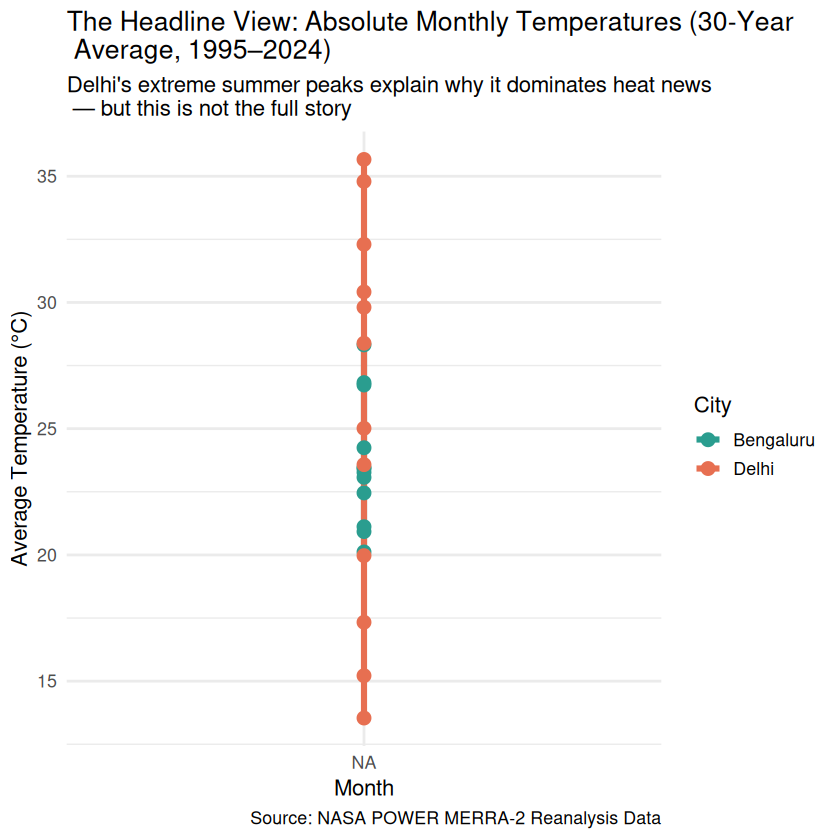

In [8]:
# ── EDA Plot 1: Seasonal profiles — the 'headline' view ──────────────────────
monthly_avg <- combined %>%
  group_by(city, month_num, month) %>%
  summarize(avg_temp = mean(temp_c, na.rm = TRUE), .groups = "drop") %>%
  mutate(month = factor(month, levels = month.abb))

ggplot(monthly_avg, aes(x = month, y = avg_temp, color = city, group = city)) +
  geom_line(linewidth = 1.3) +
  geom_point(size = 3) +
  scale_color_manual(values = c("Delhi" = "#E76F51", "Bengaluru" = "#2A9D8F")) +
  labs(
    title    = "The Headline View: Absolute Monthly Temperatures (30-Year \n Average, 1995–2024)",
    subtitle = "Delhi's extreme summer peaks explain why it dominates heat news \n — but this is not the full story",
    x        = "Month",
    y        = "Average Temperature (°C)",
    color    = "City",
    caption  = "Source: NASA POWER MERRA-2 Reanalysis Data"
  ) +
  theme_minimal(base_size = 13)

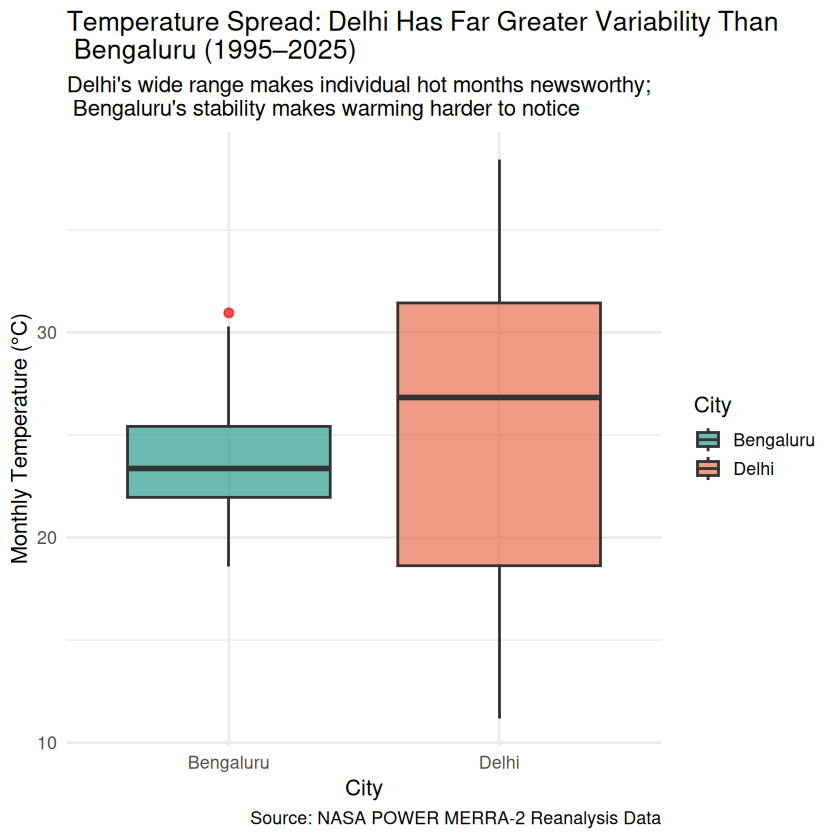

In [9]:
# ── EDA Plot 2: Boxplot — spread of temperatures across 30 years ─────────────
ggplot(combined, aes(x = city, y = temp_c, fill = city)) +
  geom_boxplot(alpha = 0.7, outlier.colour = "red", outlier.size = 2) +
  scale_fill_manual(values = c("Delhi" = "#E76F51", "Bengaluru" = "#2A9D8F")) +
  labs(
    title    = "Temperature Spread: Delhi Has Far Greater Variability Than \n Bengaluru (1995–2025)",
    subtitle = "Delhi's wide range makes individual hot months newsworthy; \n Bengaluru's stability makes warming harder to notice",
    x        = "City",
    y        = "Monthly Temperature (°C)",
    fill     = "City",
    caption  = "Source: NASA POWER MERRA-2 Reanalysis Data"
  ) +
  theme_minimal(base_size = 13)

---

## Section 5A: Which City Is Warming Faster? The Anomaly Analysis

**Relevant Lectures:**  
**Course 3, Module 10:** "Regression & Advanced Analysis" by JRS — Linear regression and trend analysis.  
**Course 5, Module 17:** "Data Visualisations and Communication" by Simon Queenborough.

The following three visualisations shift from absolute temperatures to anomalies \-\- measuring how much each city has departed from its own 30\-year normal. An upward trend means consistently warmer than baseline. A downward trend means the opposite. The steeper the upward slope, the faster the relative warming.


`geom_smooth()` using formula = 'y ~ x'


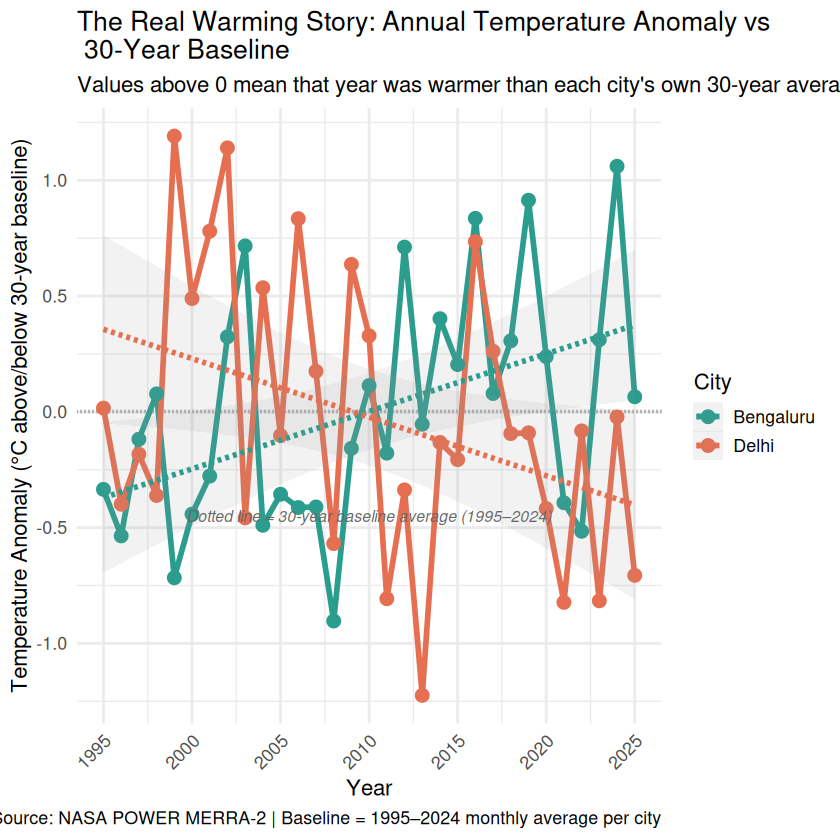

In [10]:
# ── Final Visualization 1: Annual anomaly trend — the core finding ───────────
ggplot(annual_anomaly, aes(x = year, y = mean_anomaly, color = city, group = city)) +
  geom_hline(yintercept = 0, linetype = "dotted", color = "grey50", linewidth = 0.8) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 3) +
  geom_smooth(method = "lm", se = TRUE, linetype = "dashed", alpha = 0.12) +
  scale_color_manual(values = c("Delhi" = "#E76F51", "Bengaluru" = "#2A9D8F")) +
  scale_x_continuous(breaks = seq(1995, 2025, by = 5)) +
  annotate("text", x = 2010, y = -0.45,
           label = "Dotted line = 30-year baseline average (1995–2024)",
           size = 3.2, color = "grey40", fontface = "italic") +
  labs(
    title    = "The Real Warming Story: Annual Temperature Anomaly vs \n 30-Year Baseline",
    subtitle = "Values above 0 mean that year was warmer than each city's own 30-year average",
    x        = "Year",
    y        = "Temperature Anomaly (°C above/below 30-year baseline)",
    color    = "City",
    caption  = "Source: NASA POWER MERRA-2 | Baseline = 1995–2024 monthly average per city"
  ) +
  theme_minimal(base_size = 13) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

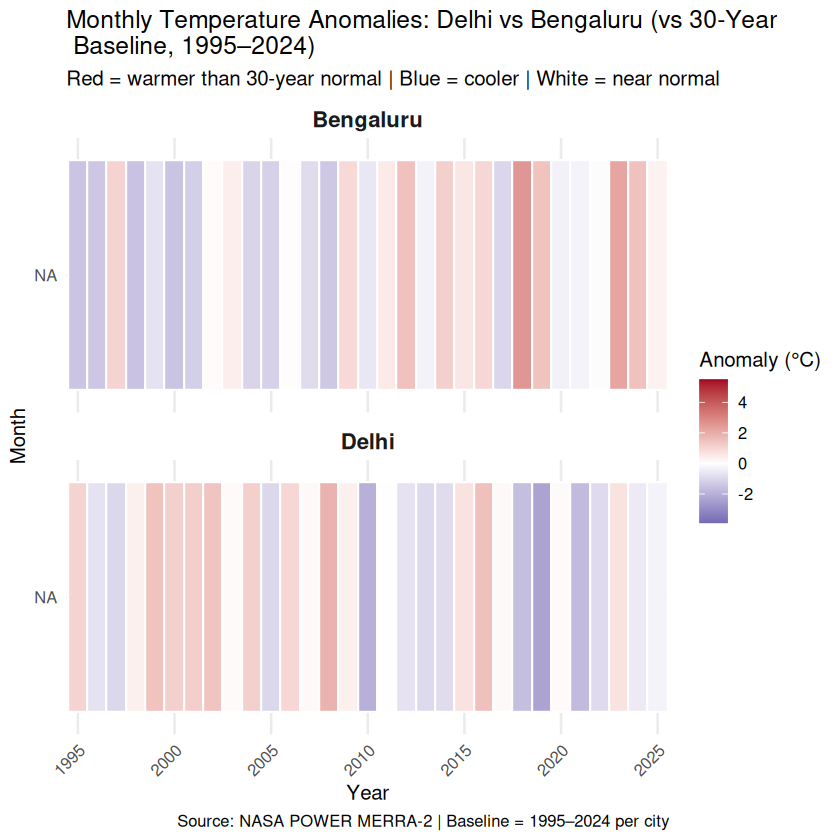

In [11]:
# ── Final Visualization 2: Monthly anomaly heatmap — both cities ──────────────
combined_heat <- combined %>%
  mutate(month = factor(month, levels = rev(month.abb)))

ggplot(combined_heat, aes(x = factor(year), y = month, fill = anomaly)) +
  geom_tile(color = "white", linewidth = 0.3) +
  scale_fill_gradient2(
    low      = "#313695",
    mid      = "white",
    high     = "#A50026",
    midpoint = 0,
    name     = "Anomaly (°C)"
  ) +
  facet_wrap(~ city, ncol = 1) +
  scale_x_discrete(breaks = as.character(seq(1995, 2025, by = 5))) +
  labs(
    title    = "Monthly Temperature Anomalies: Delhi vs Bengaluru (vs 30-Year \n Baseline, 1995–2024)",
    subtitle = "Red = warmer than 30-year normal | Blue = cooler | White = near normal",
    x        = "Year",
    y        = "Month",
    caption  = "Source: NASA POWER MERRA-2 | Baseline = 1995–2024 per city"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    strip.text   = element_text(face = "bold", size = 13),
    axis.text.x  = element_text(angle = 45, hjust = 1)
  )

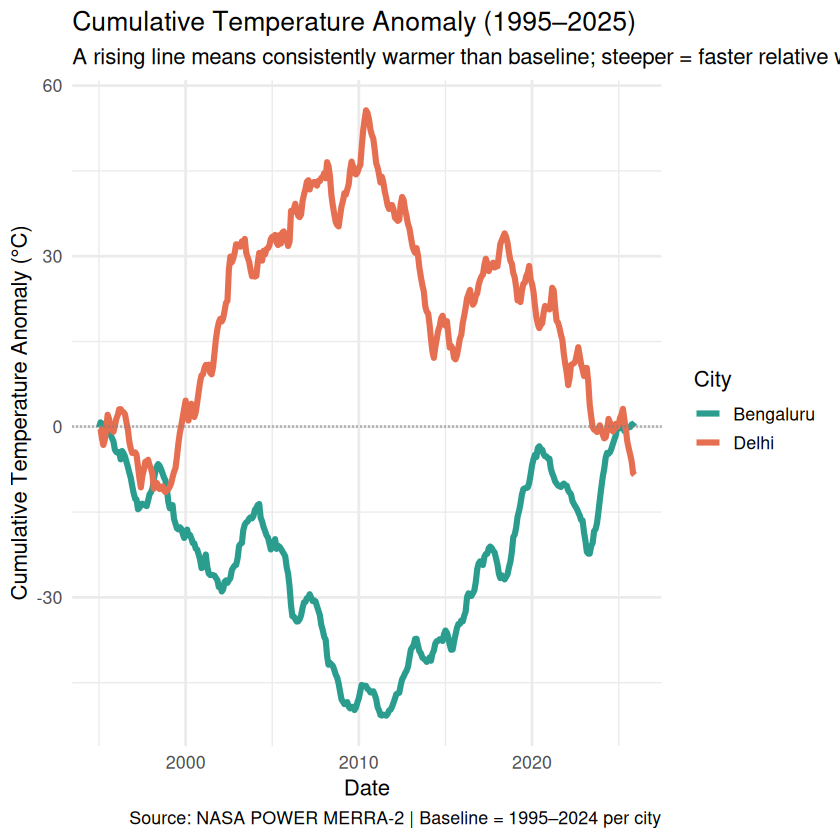

In [12]:
# ── Final Visualization 3: Cumulative anomaly — who has warmed more overall? ──
cumulative_anomaly <- combined %>%
  arrange(city, date) %>%
  group_by(city) %>%
  mutate(cumulative = cumsum(ifelse(is.na(anomaly), 0, anomaly))) %>%
  ungroup()

ggplot(cumulative_anomaly, aes(x = date, y = cumulative, color = city)) +
  geom_line(linewidth = 1.3) +
  geom_hline(yintercept = 0, linetype = "dotted", color = "grey50") +
  scale_color_manual(values = c("Delhi" = "#E76F51", "Bengaluru" = "#2A9D8F")) +
  labs(
    title    = "Cumulative Temperature Anomaly (1995–2025)",
    subtitle = "A rising line means consistently warmer than baseline; steeper = faster relative warming",
    x        = "Date",
    y        = "Cumulative Temperature Anomaly (°C)",
    color    = "City",
    caption  = "Source: NASA POWER MERRA-2 | Baseline = 1995–2024 per city"
  ) +
  theme_minimal(base_size = 13)

In [13]:
# ── Regression: Quantifying the warming rate for each city ───────────────────
# We split the dataset at 2010 to compare early vs recent warming rates
recent <- annual_anomaly %>% filter(year >= 2010)

delhi_lm     <- lm(mean_anomaly ~ year, data = recent %>% filter(city == "Delhi"))
bengaluru_lm <- lm(mean_anomaly ~ year, data = recent %>% filter(city == "Bengaluru"))

cat("=== Delhi: Warming Rate (2010–2025) ===\n")
summary(delhi_lm)

cat("\n=== Bengaluru: Warming Rate (2010–2025) ===\n")
summary(bengaluru_lm)

delhi_slope     <- round(coef(delhi_lm)["year"], 4)
bengaluru_slope <- round(coef(bengaluru_lm)["year"], 4)

cat("\n--- Summary ---\n")
cat("Delhi warming rate (2010–2025):     ", delhi_slope, "°C per year\n")
cat("Bengaluru warming rate (2010–2025): ", bengaluru_slope, "°C per year\n")
cat("\nThe city with the steeper positive slope is warming faster relative to its own 30-year baseline.\n")

=== Delhi: Warming Rate (2010–2025) ===



Call:
lm(formula = mean_anomaly ~ year, data = recent %>% filter(city == 
    "Delhi"))

Residuals:
    Min      1Q  Median      3Q     Max 
-1.0073 -0.3637  0.0680  0.2764  0.9925 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)
(Intercept) 26.53138   56.96853   0.466    0.649
year        -0.01329    0.02824  -0.471    0.645

Residual standard error: 0.5207 on 14 degrees of freedom
Multiple R-squared:  0.01557,	Adjusted R-squared:  -0.05474 
F-statistic: 0.2215 on 1 and 14 DF,  p-value: 0.6452



=== Bengaluru: Warming Rate (2010–2025) ===



Call:
lm(formula = mean_anomaly ~ year, data = recent %>% filter(city == 
    "Bengaluru"))

Residuals:
     Min       1Q   Median       3Q      Max 
-0.78480 -0.23355 -0.03521  0.23445  0.78631 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)
(Intercept) -5.351033  50.993974  -0.105    0.918
year         0.002779   0.025276   0.110    0.914

Residual standard error: 0.4661 on 14 degrees of freedom
Multiple R-squared:  0.000863,	Adjusted R-squared:  -0.0705 
F-statistic: 0.01209 on 1 and 14 DF,  p-value: 0.914



--- Summary ---


Delhi warming rate (2010–2025):      -0.0133 °C per year


Bengaluru warming rate (2010–2025):  0.0028 °C per year



The city with the steeper positive slope is warming faster relative to its own 30-year baseline.


## Section 5B: Why Is Bengaluru Warming Faster? Answer: Urbanisation

**Source**: Census of India, Office of the Registrar General & Census Commissioner, 2001 & 2011

Bengaluru grew nearly **2.5 times faster** than Delhi in the 2001–2011 decade. Rapid population growth drives urban expansion is replacing vegetation and water bodies with concrete, buildings and roads. This is the urban heat island effect: cities literally generate their own heat through density and the loss of natural cooling.


Warning message:
“The `label.size` argument of `geom_label()` is deprecated as of ggplot2 3.5.0.
ℹ Please use the `linewidth` argument instead.”


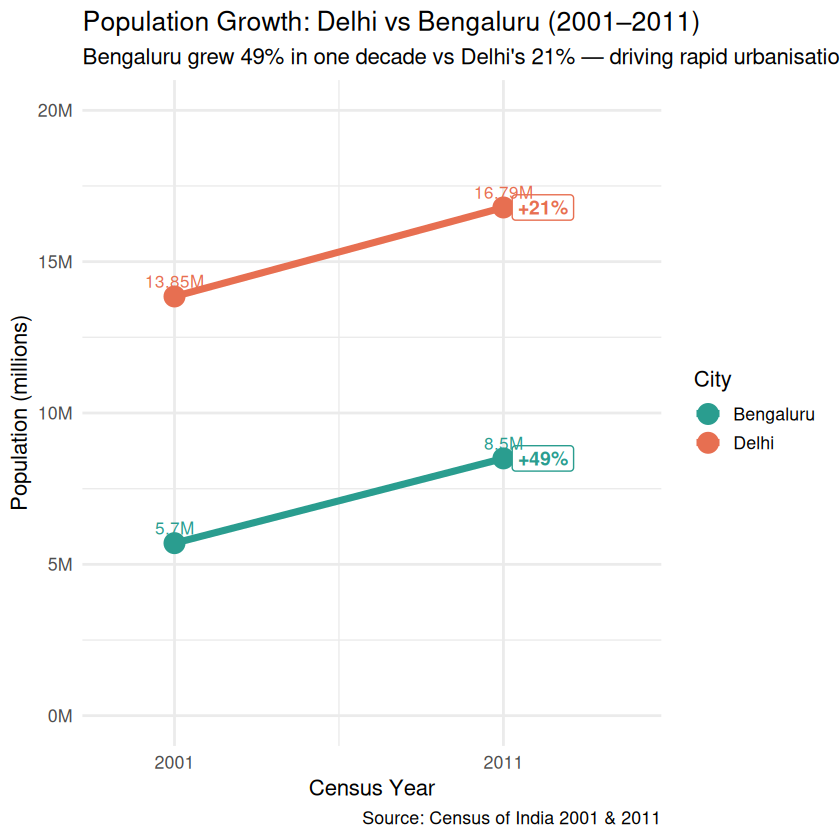

In [14]:
population <- data.frame(
  city = rep(c("Delhi", "Bengaluru"), each = 2),
  year = rep(c(2001, 2011), 2),
  population = c(13.85, 16.79, 5.70, 8.50)
)

growth_labels <- data.frame(
  city = c("Delhi", "Bengaluru"),
  year = c(2011, 2011),
  population = c(16.79, 8.50),
  label = c("+21%", "+49%")
)

ggplot(population, aes(x = year, y = population, color = city, group = city)) +
  geom_line(linewidth = 1.5) +
  geom_point(size = 5) +
  geom_label(data = growth_labels, aes(label = label, color = city),
             nudge_x = 1.2, size = 4, fontface = "bold",
             fill = "white", label.size = 0.3, show.legend = FALSE) +
  geom_text(aes(label = paste0(population, "M")),
            nudge_y = 0.5, size = 3.5, show.legend = FALSE) +
  scale_color_manual(values = c("Delhi" = "#E76F51", "Bengaluru" = "#2A9D8F")) +
  scale_x_continuous(breaks = c(2001, 2011), limits = c(1999, 2015)) +
  scale_y_continuous(labels = function(x) paste0(x, "M"), limits = c(0, 20)) +
  labs(
    title    = "Population Growth: Delhi vs Bengaluru (2001–2011)",
    subtitle = "Bengaluru grew 49% in one decade vs Delhi's 21% — driving rapid urbanisation and heat island pressure",
    x = "Census Year", y = "Population (millions)", color = "City",
    caption = "Source: Census of India 2001 & 2011"
  ) +
  theme_minimal(base_size = 13)

**What this shows:** Bengaluru added 2.8 million people in one decade \- a 49 per cent increase from a much smaller base than Delhi. This growth came primarily from the tech sector boom, which transformed agricultural and green land on the city's periphery into dense residential and commercial development. Rapid population growth is the primary driver of Bengaluru's urban heat island intensification and it happened largely without the heat risk conversation that accompanied Delhi's growth.


## Section 5C: The Cooling Infrastructure Collapse \-\- Tree Cover Loss

**Source:** Global Forest Watch, Hansen/UMD/Google/USGS/NASA  

**Level:** Bengaluru Urban District & NCT of Delhi | Period: 2001–2024

Both cities had almost no tree cover left by 2000 \- Delhi had 262 hectares, Bengaluru just 162 hectares, each less than 0.2 per cent of their total land area. What the data tracks is the loss of these last remnants.


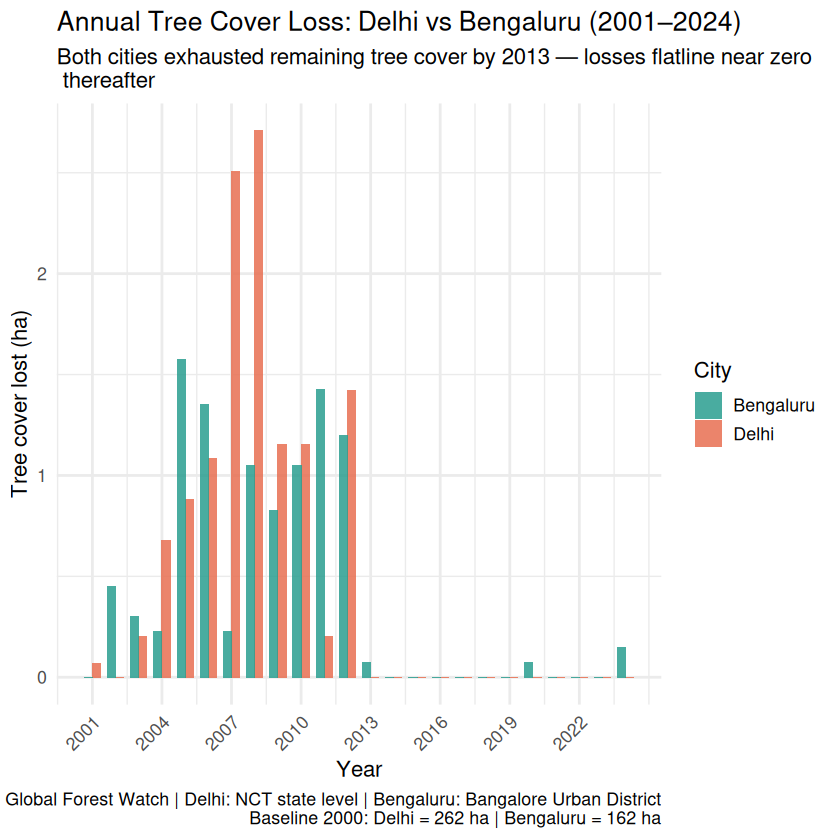

In [15]:
library(readr)

# Read Delhi tree cover loss from zip
delhi_trees <- read_csv(
  unz("Tree cover loss in NCT of Delhi, India.zip", "treecover_loss__ha.csv"),
  show_col_types = FALSE
)

# Read Bengaluru tree cover loss from zip
blr_trees <- read_csv(
  unz("Tree cover loss in Bangalore, Karnataka, India.zip", "treecover_loss__ha.csv"),
  show_col_types = FALSE
)

# Prepare combined dataset
all_years <- data.frame(year = 2001:2024)

delhi_y <- delhi_trees %>%
  rename(year = umd_tree_cover_loss__year, delhi = umd_tree_cover_loss__ha) %>%
  select(year, delhi)

blr_y <- blr_trees %>%
  rename(year = umd_tree_cover_loss__year, bengaluru = umd_tree_cover_loss__ha) %>%
  select(year, bengaluru)

tree_combined <- all_years %>%
  left_join(delhi_y, by = "year") %>%
  left_join(blr_y, by = "year") %>%
  replace(is.na(.), 0) %>%
  pivot_longer(cols = c(delhi, bengaluru),
               names_to = "city", values_to = "loss_ha") %>%
  mutate(city = ifelse(city == "delhi", "Delhi", "Bengaluru"))

ggplot(tree_combined, aes(x = year, y = loss_ha, fill = city)) +
  geom_col(position = "dodge", width = 0.7, alpha = 0.85) +
  scale_fill_manual(values = c("Delhi" = "#E76F51", "Bengaluru" = "#2A9D8F")) +
  scale_x_continuous(breaks = seq(2001, 2024, by = 3)) +
  labs(
    title    = "Annual Tree Cover Loss: Delhi vs Bengaluru (2001–2024)",
    subtitle = "Both cities exhausted remaining tree cover by 2013 — losses flatline near zero \n thereafter",
    x = "Year", y = "Tree cover lost (ha)", fill = "City",
    caption = "Source: Global Forest Watch | Delhi: NCT state level | Bengaluru: Bangalore Urban District\nBaseline 2000: Delhi = 262 ha | Bengaluru = 162 ha"
  ) +
  theme_minimal(base_size = 13) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

**What this shows:** By 2000, Bengaluru had just 162 hectares of tree cover \- 0.07 per cent of its total land area. The heaviest losses occurred between 2005 and 2012 during the first wave of tech\-sector construction. After 2013 losses reach near zero, not because the city stopped expanding, but because there was almost nothing left. Bengaluru's natural cooling infrastructure is essentially gone. Delhi had almost no tree cover to begin with, and its heat is climatic and structural. Bengaluru's warming is driven by the active destruction of the features that historically made it temperate.


## Section 5D: The Perception Gap \-\- Do Residents Feel the Heat?

**Source**: Yale India Climate Opinion Maps, Yale Program on Climate Change Communication, November 2025

**Citation:** Marlon, J., Leiserowitz, A., Thaker, J., et al. \(2024\). Variations in Climate Opinions Across India. Yale University.

**Level:** Delhi = state | Bengaluru = Karnataka, Bangalore district

If Bengaluru is warming faster on a relative basis, do its residents know it? The Yale India Climate Opinion Maps provide modelled estimates of climate attitudes based on nationally representative surveys, allowing a direct comparison of what Delhi and Bengaluru residents believe about heat.


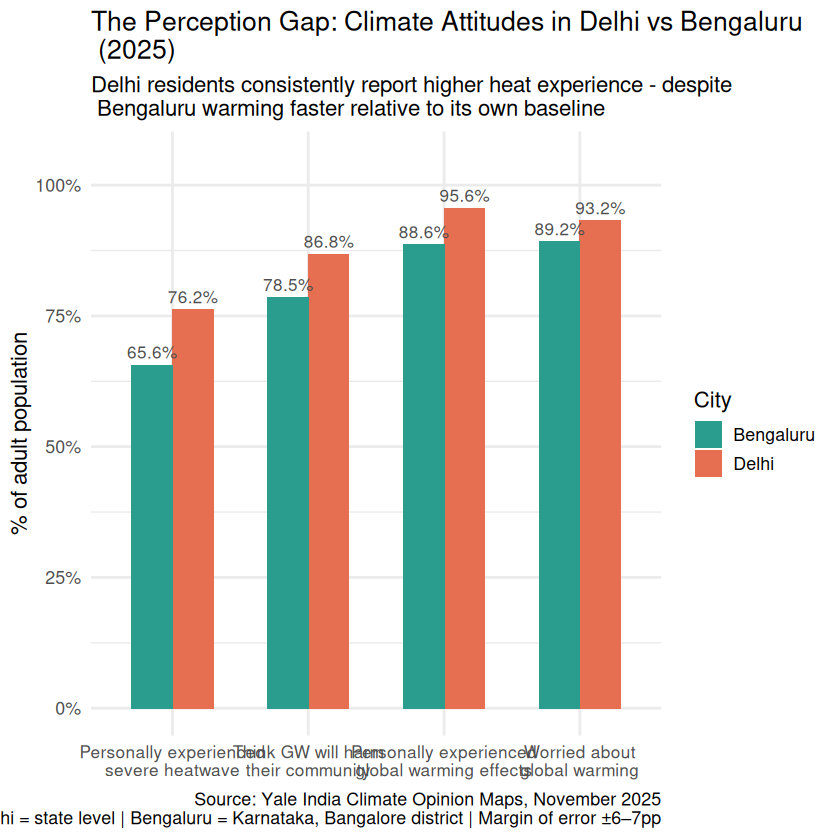

In [16]:
library(readxl)

yale <- read_excel("IndiaMRP1.5_publicdata.xlsx", sheet = "India_2025")

# Extract Delhi state and Bengaluru district
delhi_survey     <- yale %>% filter(GeoType == "state",    GeoName == "Delhi")
bengaluru_survey <- yale %>% filter(GeoType == "district", GeoName == "Karnataka, Bangalore")

perception <- data.frame(
  city = rep(c("Delhi", "Bengaluru"), 4),
  question = rep(c(
    "Personally experienced\nsevere heatwave",
    "Personally experienced\nglobal warming effects",
    "Think GW will harm\ntheir community",
    "Worried about\nglobal warming"
  ), each = 2),
  percent = c(
    76.2, 65.6,
    95.6, 88.6,
    86.8, 78.5,
    93.2, 89.2
  )
)

perception$question <- factor(perception$question, levels = c(
  "Personally experienced\nsevere heatwave",
  "Think GW will harm\ntheir community",
  "Personally experienced\nglobal warming effects",
  "Worried about\nglobal warming"
))

ggplot(perception, aes(x = question, y = percent, fill = city)) +
  geom_col(position = "dodge", width = 0.6) +
  geom_text(aes(label = paste0(percent, "%")),
            position = position_dodge(width = 0.6),
            vjust = -0.5, size = 3.5, color = "grey30") +
  scale_fill_manual(values = c("Delhi" = "#E76F51", "Bengaluru" = "#2A9D8F")) +
  scale_y_continuous(limits = c(0, 105), labels = function(x) paste0(x, "%")) +
  labs(
    title    = "The Perception Gap: Climate Attitudes in Delhi vs Bengaluru \n (2025)",
    subtitle = "Delhi residents consistently report higher heat experience - despite \n Bengaluru warming faster relative to its own baseline",
    x = NULL, y = "% of adult population", fill = "City",
    caption = "Source: Yale India Climate Opinion Maps, November 2025\nDelhi = state level | Bengaluru = Karnataka, Bangalore district | Margin of error ±6–7pp"
  ) +
  theme_minimal(base_size = 13) +
  theme(axis.text.x = element_text(size = 10))

**What this shows:** 76.2 per cent of Delhi residents report personally experiencing a severe heatwave in the past year, compared to 65.6 per cent in Bengaluru \- a gap of 10.6 percentage points. Delhi residents are also more worried, more likely to feel their community is at risk, and more likely to report experiencing global warming effects. This perception gap is the real\-world consequence of the media framing this project challenges. Cities where residents feel less threatened by heat are cities where political pressure for heat adaptation policy is lower, even when the underlying warming trend is accelerating.


## Section 6: Ethical Considerations

**Relevant Lectures:** Course 2, Module 5: "Data Sources & Preprocessing" on responsible use of public datasets.

**Privacy:** No personal data is used. All data is derived from satellite\-based atmospheric measurements.

**Governance:** NASA POWER data is publicly available under an open\-access license, free for research and educational use.

**Bias:** Two forms of bias are relevant here. First, the MERRA\-2 model averages temperature over a 50 km2 grid cell, potentially smoothing over hyper\-local heat concentrations in dense urban cores. Second, and central to this project's argument, **media bias** in how heat is reported creates a distorted public understanding of which cities are at risk. Coverage focused on absolute peak temperatures systematically advantages cities like Delhi \(already hot\) and obscures warming in cities like Bengaluru \(warming from a milder baseline\).

**Equity:** Urban heat disproportionately affects outdoor workers, low\-income communities, and the elderly \-\- groups with the least access to cooling. This analysis does not disaggregate by socioeconomic status, which would be necessary before drawing detailed policy conclusions.


## Section 7: Acknowledging Limitations

**Relevant Lectures:**  
**Course 3, Module 8:** "Handling Data Anomalies" by Angel.

This analysis uses a 30\-year baseline \(1995–2024\), consistent with scientific standards for climate normals. The T2M variable measures near\-surface air temperature rather than land surface temperature, so it may underestimate street\-level urban heat. The 30\-year baseline period itself includes the warming trend being studied, which slightly compresses the anomaly values \- a longer pre\-industrial baseline would produce larger anomalies. Finally, this analysis covers only two cities but a fuller study would include Chennai, Mumbai, Hyderabad, and other major Indian metros to determine whether Bengaluru's relative warming trend is distinctive or widespread.

---

## Section 8: Results for a Non-Technical Audience

**Relevant Lectures:**  
**Course 5, Module 15:** "Turning Data into Action" by Denice Ross.

When you read about heat in India, it is almost always about Delhi. And with good reason \- Delhi's summers are brutal, regularly breaching 45C. But there is a critical difference between a city being hot and a city _getting hotter_.

This project asks a different question: compared to what each city used to be over the past 30 years, which one has changed more? Using NASA satellite data from 1995 to 2025, we measure each city against its own long\-term average.

The findings challenge the assumption that Delhi is India's most alarming urban heat story. Bengaluru \- historically mild, elevated, and green \- has undergone a dramatic transformation. Millions of new residents, the loss of lakes and forests to concrete, and unchecked urban sprawl have all pushed its temperatures upward in ways its pleasant reputation obscures.

The risk is that cities that do not make heat headlines do not get heat policy. If Bengaluru is warming faster on a relative basis, its residents, planners, and governments need to know, and the current media framing of urban heat in India is not telling them.

---

## Section 9: Instructions for Reproducing This Project

**Relevant Lectures:**  
**Course 2, Module 6:** "Addressing Version Control and Reproducibility" by Mitch.

1. Clone the GitHub repository: `git clone https://github.com/stutimishra11/urban-heat-india-capstone`
2. Install R \(version 4.0\+\) and required packages:
   ```r
   install.packages(c("dplyr", "ggplot2", "tidyr", "readr"))
   ```
3. Open `notebooks/urban-heat-india-capstone.ipynb` in CoCalc or JupyterLab with the R kernel selected.
4. All data files are in the data/ folder including NASA POWER CSVs, Census data, Global Forest Watch zip files, and Yale Climate Opinion Maps \-\- no external downloads needed.
5. Run all cells from top to bottom. All outputs and visualisations reproduce automatically.

